In [1]:
# =========================
# Cell 1: Imports
# =========================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# =========================
# Cell 2: Dataset Path
# =========================

DATASET_PATH = r"E:\WISDM_ar_v1.1\PAMAP2_Dataset"

protocol_path = os.path.join(DATASET_PATH, "Protocol")
files = sorted(glob.glob(os.path.join(protocol_path, "*.dat")))

print("Total subject files found:", len(files))
for f in files:
    print(os.path.basename(f))

Total subject files found: 9
subject101.dat
subject102.dat
subject103.dat
subject104.dat
subject105.dat
subject106.dat
subject107.dat
subject108.dat
subject109.dat


In [3]:
# =========================
# Cell 3: PAMAP2 Activity Labels
# =========================

activity_map = {
    1: "Lying",
    2: "Sitting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    7: "Nordic Walking",
    9: "Watching TV",
    10: "Computer Work",
    11: "Car Driving",
    12: "Ascending Stairs",
    13: "Descending Stairs",
    16: "Vacuum Cleaning",
    17: "Ironing",
    18: "Folding Laundry",
    19: "House Cleaning",
    20: "Playing Soccer",
    24: "Rope Jumping"
}

# Common 12-class PAMAP2 activities used in HAR papers
selected_activities = {
    1: "Lying",
    2: "Sitting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    7: "Nordic Walking",
    12: "Ascending Stairs",
    13: "Descending Stairs",
    16: "Vacuum Cleaning",
    17: "Ironing",
    24: "Rope Jumping"
}

In [4]:
import os
import glob

DATASET_PATH = r"E:\WISDM_ar_v1.1\PAMAP2_Dataset"

protocol_path = os.path.join(DATASET_PATH, "Protocol")

files = sorted(glob.glob(os.path.join(protocol_path, "*.dat")))

print("Protocol path:")
print(protocol_path)

print("\nNumber of files found:", len(files))

for f in files:
    print(os.path.basename(f))

Protocol path:
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol

Number of files found: 9
subject101.dat
subject102.dat
subject103.dat
subject104.dat
subject105.dat
subject106.dat
subject107.dat
subject108.dat
subject109.dat


In [5]:
print("Number of files:", len(files))

for f in files:
    print(f)

Number of files: 9
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject101.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject102.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject103.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject104.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject105.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject106.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject107.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject108.dat
E:\WISDM_ar_v1.1\PAMAP2_Dataset\Protocol\subject109.dat


In [8]:
# ==========================
# Load PAMAP2 Dataset
# ==========================

all_data = []

for file in files:

    df = pd.read_csv(
        file,
        sep=r"\s+",
        header=None
    )

    all_data.append(df)

pamap2 = pd.concat(all_data, ignore_index=True)

print("Dataset Shape :", pamap2.shape)

pamap2.head()

Dataset Shape : (2872533, 54)


,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,...,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,...,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,...,0.003175,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,...,0.012698,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0


In [9]:
pamap2 = pamap2.rename(columns={
    0: 'timestamp',
    1: 'activity_id',

    21: 'chest_acc16_x',
    22: 'chest_acc16_y',
    23: 'chest_acc16_z'
})

In [10]:
selected_activities = {
    1: "Lying",
    2: "Sitting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    7: "Nordic Walking",
    12: "Ascending Stairs",
    13: "Descending Stairs",
    16: "Vacuum Cleaning",
    17: "Ironing",
    24: "Rope Jumping"
}

pamap2 = pamap2[pamap2['activity_id'].isin(selected_activities)]

pamap2['activity'] = pamap2['activity_id'].map(selected_activities)

print(pamap2['activity'].value_counts())

activity
Walking              238761
Ironing              238690
Lying                192523
Standing             189931
Nordic Walking       188107
Sitting              185188
Vacuum Cleaning      175353
Cycling              164600
Ascending Stairs     117216
Descending Stairs    104944
Running               98199
Rope Jumping          49360
Name: count, dtype: int64


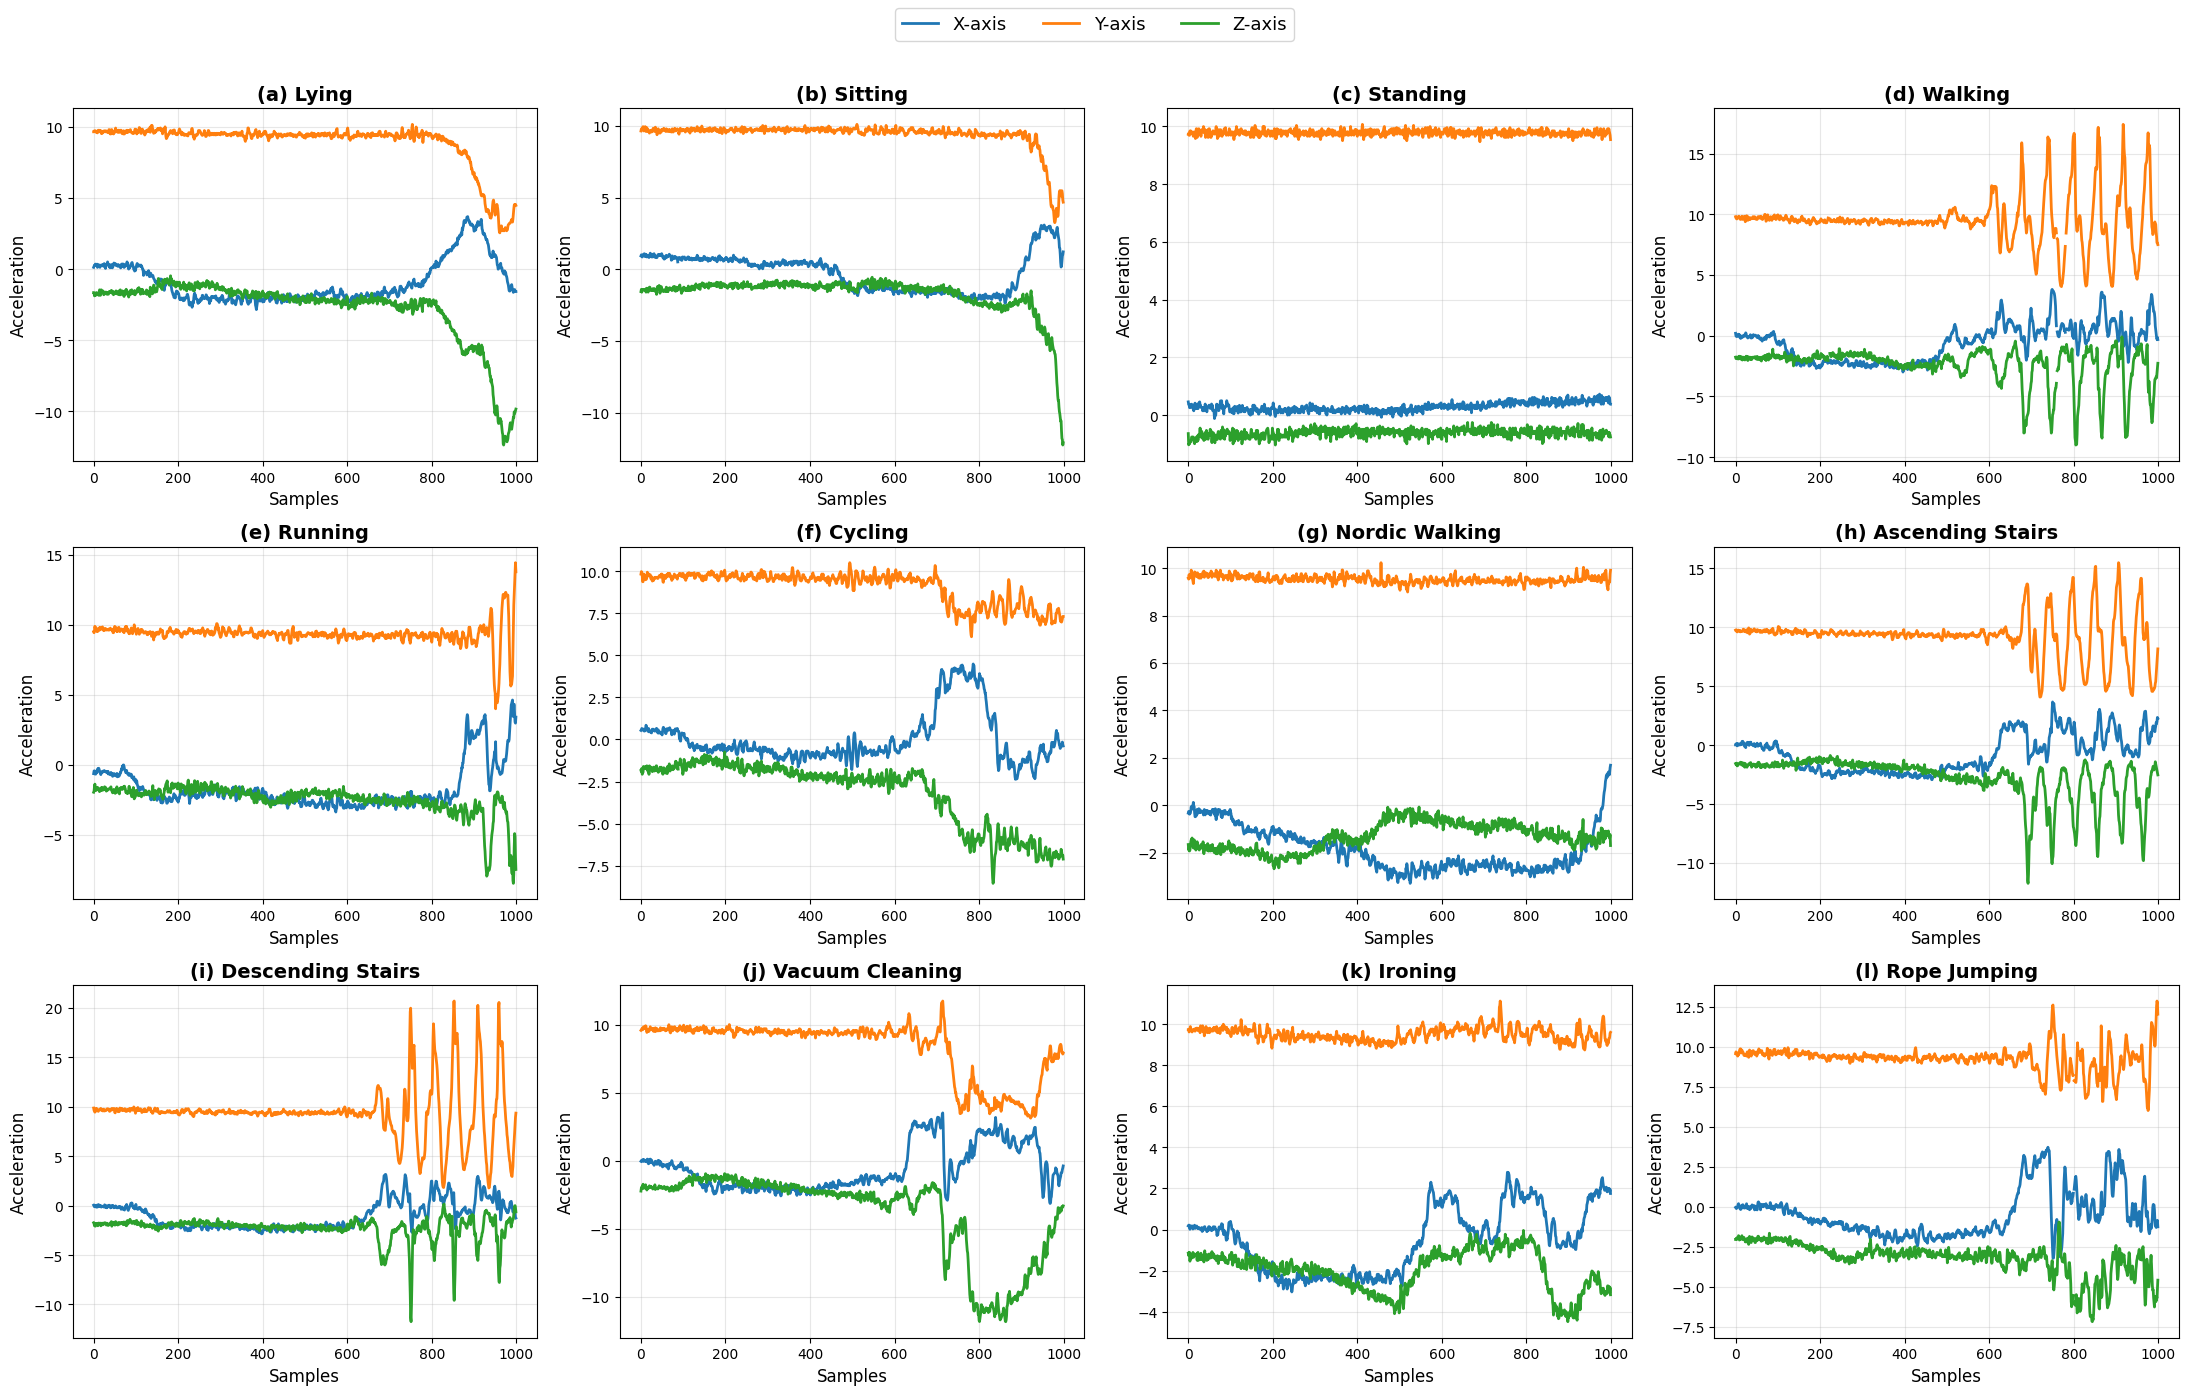

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(22, 14))

activities = list(selected_activities.values())

for i, activity in enumerate(activities):

    ax = axes.flat[i]

    temp = pamap2[pamap2['activity'] == activity].iloc[:1000]

    ax.plot(temp['chest_acc16_x'].values,
            linewidth=2,
            label='X-axis')

    ax.plot(temp['chest_acc16_y'].values,
            linewidth=2,
            label='Y-axis')

    ax.plot(temp['chest_acc16_z'].values,
            linewidth=2,
            label='Z-axis')

    ax.set_title(f"({chr(97+i)}) {activity}",
                 fontsize=14,
                 fontweight='bold')

    ax.set_xlabel("Samples", fontsize=12)
    ax.set_ylabel("Acceleration", fontsize=12)

    ax.tick_params(axis='both',
                   labelsize=10)

    ax.grid(alpha=0.3)


# Single legend for complete figure
handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(handles,
           labels,
           loc='upper center',
           ncol=3,
           fontsize=13,
           frameon=True)

plt.tight_layout(rect=[0,0,1,0.95])

plt.savefig("PAMAP2_Signals_HighQuality.png",
            dpi=600,
            bbox_inches='tight')

plt.show()

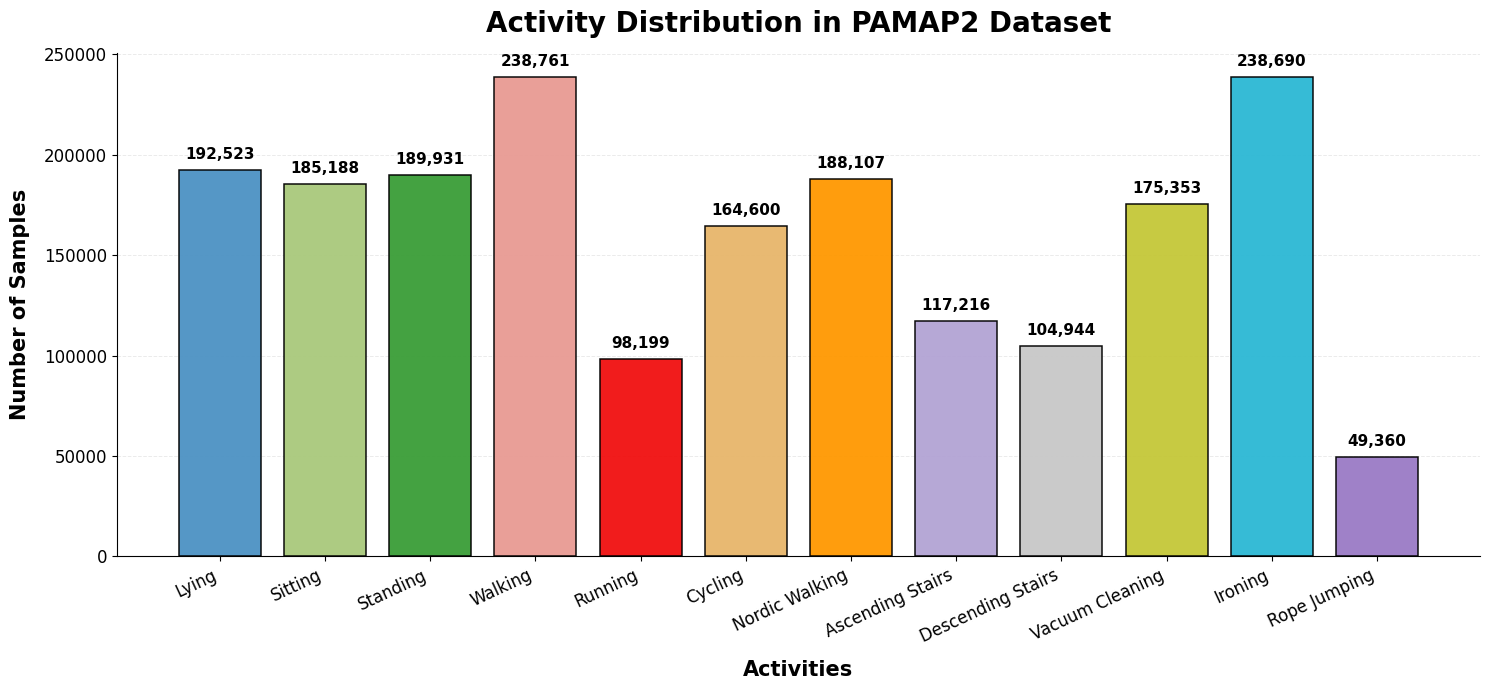

In [ ]:
# ====================================================
# PAMAP2 Activity Distribution Figure
# ====================================================

import matplotlib.pyplot as plt

activities = [
    "Lying", "Sitting", "Standing", "Walking",
    "Running", "Cycling", "Nordic Walking",
    "Ascending Stairs", "Descending Stairs",
    "Vacuum Cleaning", "Ironing", "Rope Jumping"
]

counts = pamap2["activity"].value_counts().reindex(activities)

colors = [
    "#4C92C3", "#A9C97B", "#3A9D37", "#E89A93",
    "#F10F0A", "#E7B66A", "#FF9800", "#B2A3D4",
    "#C8C8C8", "#C4C738", "#2BB8D4", "#9A7AC5"
]

plt.style.use("default")

fig, ax = plt.subplots(figsize=(15, 7), facecolor="white")
ax.set_facecolor("white")

bars = ax.bar(
    activities,
    counts.values,
    width=0.78,
    color=colors,
    edgecolor="black",
    linewidth=1.1,
    alpha=0.95
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 4000,
        f"{int(h):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Activity Distribution",
    fontsize=20,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Activities", fontsize=15, fontweight="bold", labelpad=10)
ax.set_ylabel("Number of Samples", fontsize=15, fontweight="bold", labelpad=10)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.xticks(rotation=25, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "PAMAP2_Activity_Distribution_Improved.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [18]:
pamap2 = pamap2.rename(columns={
    21:'chest_acc16_x',
    22:'chest_acc16_y',
    23:'chest_acc16_z'
})

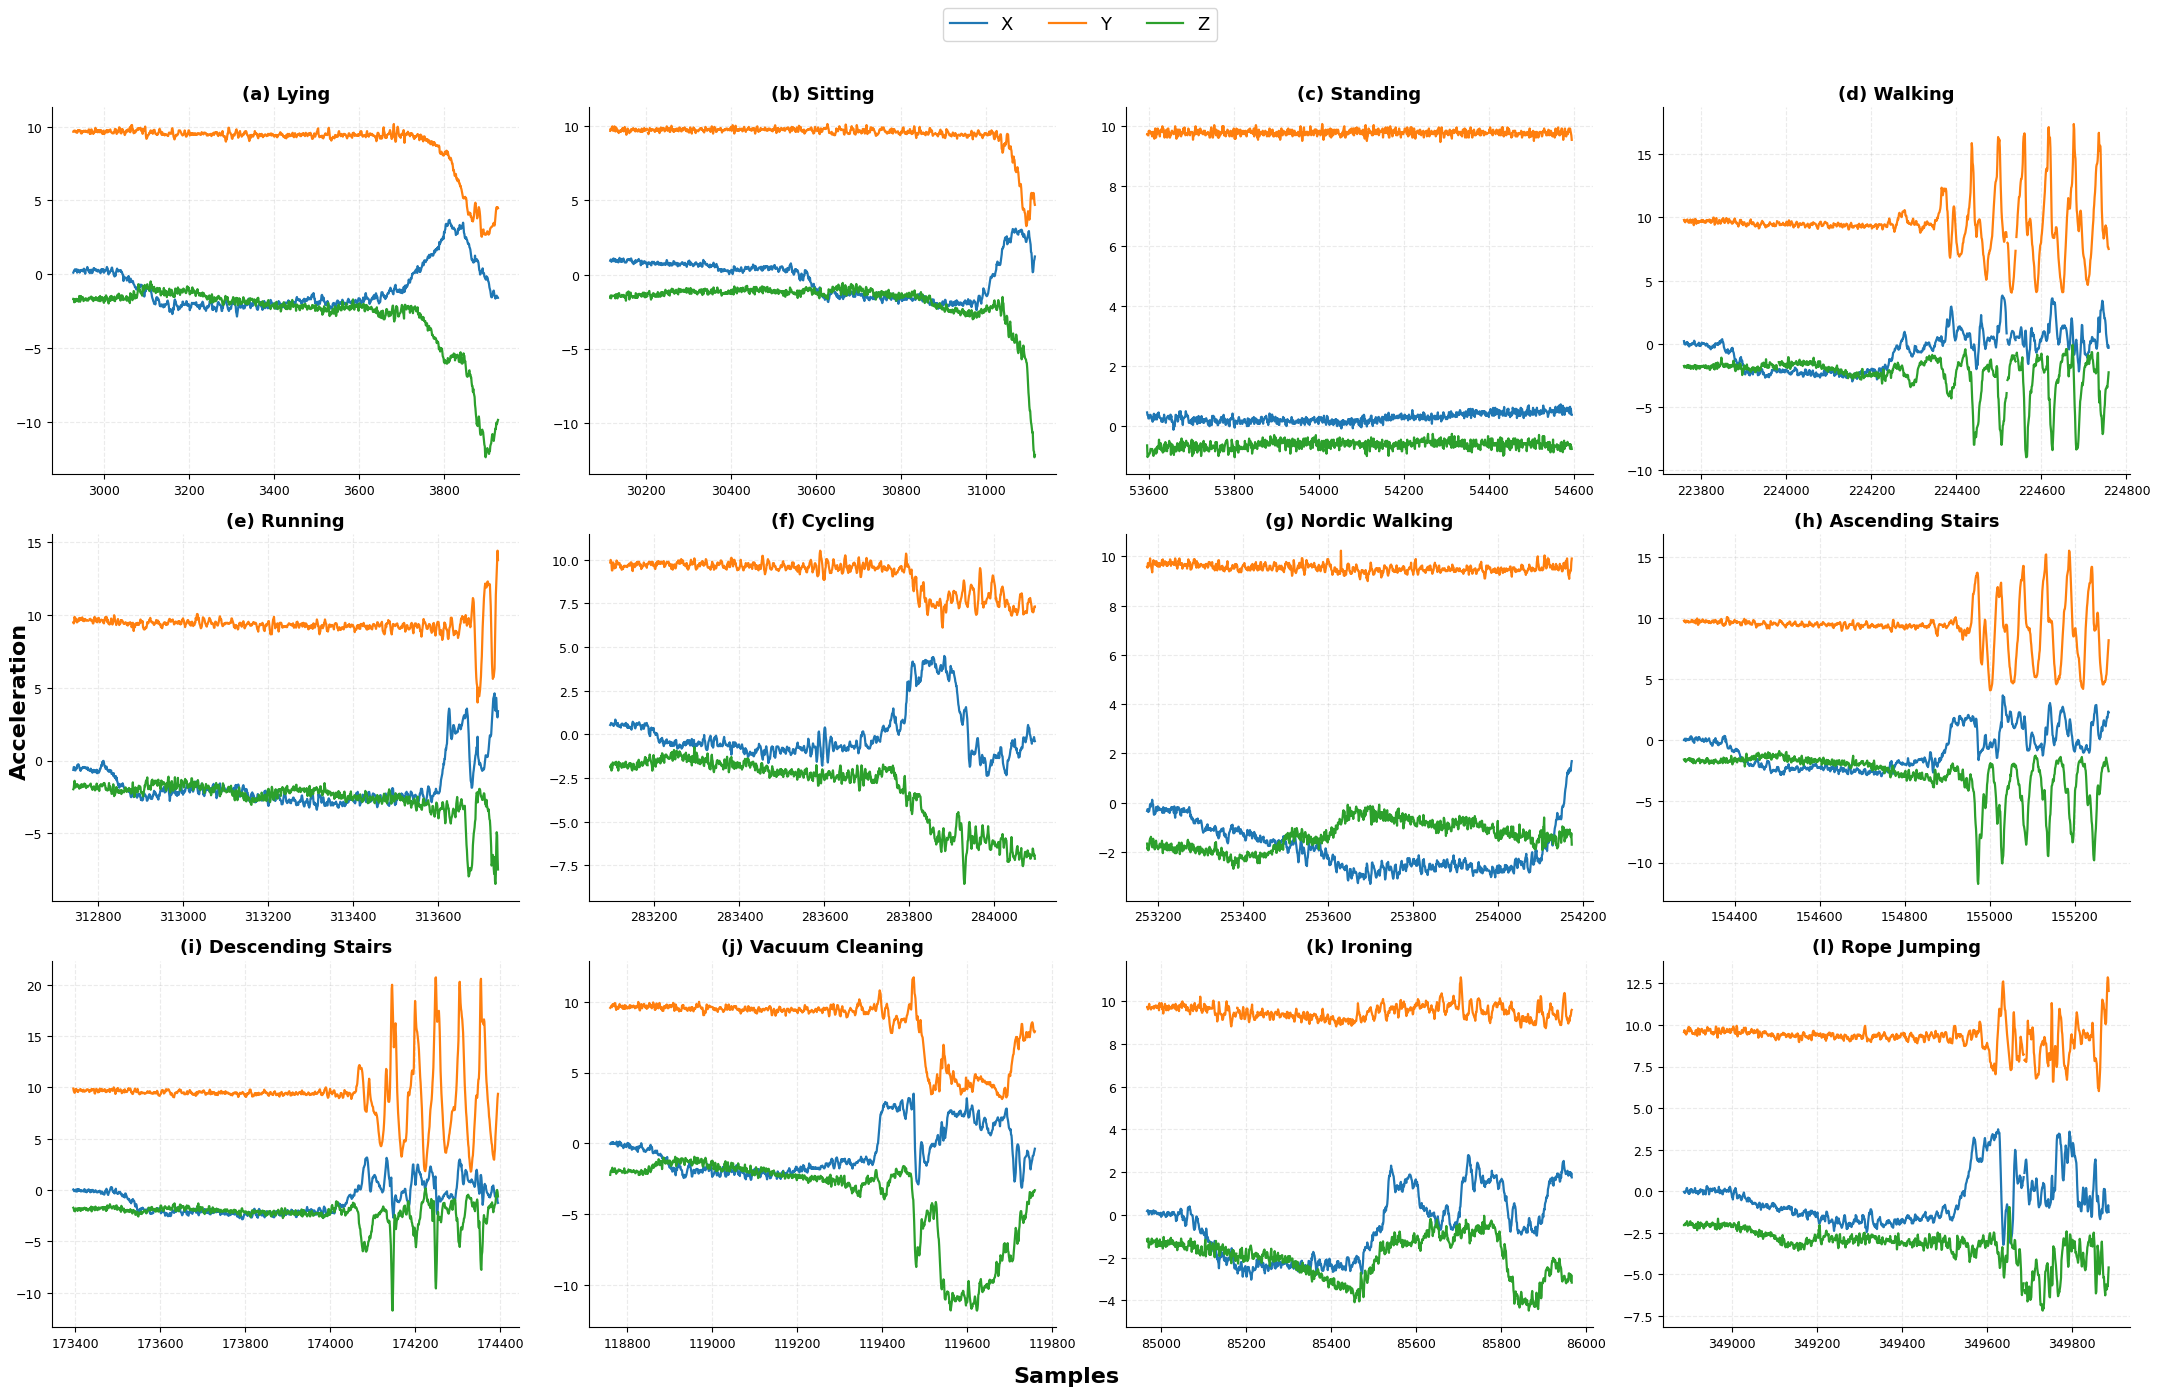

In [19]:
# ==========================================================
# Figure 2: Chest Accelerometer Signals for 12 Activities
# ==========================================================

import matplotlib.pyplot as plt

activities = [
    "Lying",
    "Sitting",
    "Standing",
    "Walking",
    "Running",
    "Cycling",
    "Nordic Walking",
    "Ascending Stairs",
    "Descending Stairs",
    "Vacuum Cleaning",
    "Ironing",
    "Rope Jumping"
]

letters = list("abcdefghijkl")

fig, axes = plt.subplots(
    3,
    4,
    figsize=(22, 14)
)

for i, activity in enumerate(activities):

    ax = axes.flat[i]

    data = pamap2[pamap2['activity'] == activity]

    # show first 1000 samples
    data = data.iloc[:1000]

    ax.plot(
        data['chest_acc16_x'],
        color='#1f77b4',
        linewidth=1.6,
        label='X'
    )

    ax.plot(
        data['chest_acc16_y'],
        color='#ff7f0e',
        linewidth=1.6,
        label='Y'
    )

    ax.plot(
        data['chest_acc16_z'],
        color='#2ca02c',
        linewidth=1.6,
        label='Z'
    )

    ax.set_title(
        f"({letters[i]}) {activity}",
        fontsize=13,
        fontweight='bold'
    )

    ax.grid(
        linestyle='--',
        alpha=0.25
    )

    ax.tick_params(
        labelsize=9
    )

    # cleaner appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



# Shared labels
fig.supxlabel(
    'Samples',
    fontsize=16,
    fontweight='bold'
)

fig.supylabel(
    'Acceleration',
    fontsize=16,
    fontweight='bold'
)


# One legend for the whole figure
handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=3,
    fontsize=13,
    frameon=True
)


plt.tight_layout(
    rect=[0,0,1,0.95]
)


plt.savefig(
    'PAMAP2_ChestSignals.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [21]:
# ==========================================================
# Reload PAMAP2 with subject and activity columns
# ==========================================================

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

DATASET_PATH = r"E:\WISDM_ar_v1.1\PAMAP2_Dataset"
protocol_path = os.path.join(DATASET_PATH, "Protocol")
files = sorted(glob.glob(os.path.join(protocol_path, "*.dat")))

all_data = []

for file in files:
    subject_id = os.path.basename(file).replace(".dat", "")

    df = pd.read_csv(file, sep=r"\s+", header=None)

    df["subject"] = subject_id
    df = df.rename(columns={1: "activity_id"})

    all_data.append(df)

pamap2 = pd.concat(all_data, ignore_index=True)

selected_activities = {
    1: "Lying",
    2: "Sitting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    7: "Nordic Walking",
    12: "Ascending Stairs",
    13: "Descending Stairs",
    16: "Vacuum Cleaning",
    17: "Ironing",
    24: "Rope Jumping"
}

pamap2 = pamap2[pamap2["activity_id"].isin(selected_activities.keys())].copy()
pamap2["activity"] = pamap2["activity_id"].map(selected_activities)

print(pamap2[["subject", "activity_id", "activity"]].head())

         subject  activity_id activity
2928  subject101            1    Lying
2929  subject101            1    Lying
2930  subject101            1    Lying
2931  subject101            1    Lying
2932  subject101            1    Lying


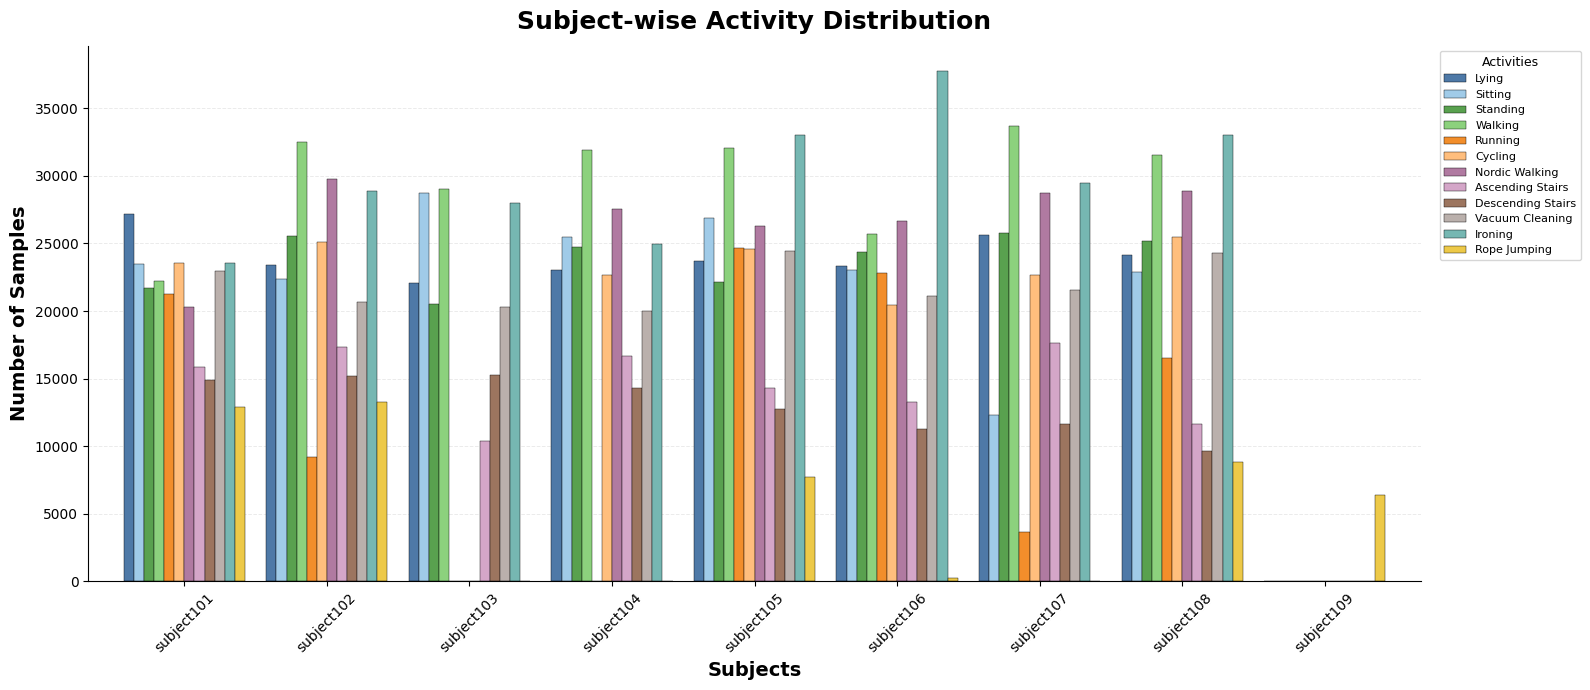

In [25]:
# ==========================================================
# Figure: Subject-wise Activity Distribution in PAMAP2 Dataset
# ==========================================================

import matplotlib.pyplot as plt

activities = [
    "Lying", "Sitting", "Standing", "Walking",
    "Running", "Cycling", "Nordic Walking",
    "Ascending Stairs", "Descending Stairs",
    "Vacuum Cleaning", "Ironing", "Rope Jumping"
]

# Journal-friendly color palette
colors = [
    '#4E79A7',  # muted blue
    '#A0CBE8',  # light blue
    '#59A14F',  # green
    '#8CD17D',  # light green
    '#F28E2B',  # orange
    '#FFBE7D',  # light orange
    '#B07AA1',  # purple
    '#D4A6C8',  # lavender
    '#9C755F',  # brown
    '#BAB0AC',  # gray
    '#76B7B2',  # teal
    '#EDC948'   # yellow
]

# Count samples for each subject and activity
subject_activity_counts = (
    pamap2
    .groupby(["subject", "activity"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=activities)
)

plt.style.use("default")

fig, ax = plt.subplots(figsize=(16,7), facecolor='white')
ax.set_facecolor('white')

subject_activity_counts.plot(
    kind='bar',
    ax=ax,
    width=0.85,
    color=colors,
    edgecolor='black',
    linewidth=0.3
)

# Title
ax.set_title(
    "Subject-wise Activity Distribution",
    fontsize=18,
    fontweight='bold',
    pad=12
)

# Labels
ax.set_xlabel(
    "Subjects",
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    "Number of Samples",
    fontsize=14,
    fontweight='bold'
)

# Tick formatting
ax.tick_params(
    axis='x',
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis='y',
    labelsize=10
)

# Light grid
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

# Cleaner appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(
    title='Activities',
    fontsize=8,
    title_fontsize=9,
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    frameon=True
)

plt.tight_layout()

plt.savefig(
    "PAMAP2_Subjectwise_Activity_Distribution.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()